# Import Required Libraries

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import adi
import binascii

# Plotting Functions

In [108]:
def plot_scatter(signal):
    plt.figure(figsize=(3, 3))
    plt.scatter(signal.real, signal.imag, color='blue', alpha=0.5, s=30)
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

def plot_signal(signal, length, label_name, color_name):
    plt.figure(figsize=(15, 3))
    plt.plot(signal[:length], '.-', label = label_name, color = color_name)
    plt.grid(True)
    plt.legend()
    plt.show()

def text_to_bin(text):
    temp_bin_str = ''.join(format(ord(c), '07b') for c in text)
    bin_data = np.array([int(bit) for bit in temp_bin_str], dtype=int)
    return bin_data

def append_crc_to_frame(payload):
    byte_data = np.packbits(payload)  
    crc = binascii.crc_hqx(byte_data, 0xFFFF)  
    crc_bits = np.array(list(np.binary_repr(crc, width=16)), dtype=np.uint8)  
    return np.concatenate((payload, crc_bits))

# Source Coding

### Text to ASCII, ASCII to binary


In [109]:
text_message = '''In the digital age, privacy has become one of the most debated and critical issues. With every click, swipe, and search, individuals leave behind a trail of data. This data, often collected without explicit consent, is used by corporations, advertisers, and sometimes even governments. While digital tools offer convenience and personalization, they also raise concerns about surveillance, data breaches, and identity theft. People are increasingly aware of how their personal information is being tracked, stored, and monetized. As a result, calls for stronger privacy regulations, ethical data practices, and transparent technology use are gaining momentum around the world, prompting urgent discussions.

Digital privacy has become a defining concern of the 21st century, shaping the way individuals, businesses, and governments interact online. As our dependence on digital technologies grows, so does the amount of data we generate-often unknowingly. From smartphones and smartwatches to social media platforms and online banking, our digital footprint expands with every interaction, posing significant challenges to personal privacy and data security.

The convenience of digital services comes at a price. Search engines track our queries, social media apps monitor our behaviors, and e-commerce websites analyze our shopping habits. While this data collection helps companies offer personalized experiences and targeted advertising, it often occurs without clear user consent or understanding. The question arises: how much privacy are we sacrificing for convenience?

Data breaches have become alarmingly common. High-profile incidents involving companies like Equifax, Facebook, and Marriott have exposed millions of users’ personal information, including names, addresses, passwords, and even financial details. These breaches not only compromise user security but also erode trust in digital platforms. Once private data is leaked, it can be exploited by cybercriminals for identity theft, financial fraud, or blackmail.

Governments are also involved in digital surveillance, often citing national security concerns. Programs like PRISM, revealed by Edward Snowden in 2013, demonstrated how intelligence agencies could access data from major tech companies without users’ knowledge. While some argue this surveillance helps prevent crime and terrorism, critics warn it threatens civil liberties and the right to privacy. In authoritarian regimes, surveillance tools are sometimes used to monitor political opponents, journalists, and activists.

In response to these concerns, countries have started implementing stronger data protection laws. The European Union’s General Data Protection Regulation (GDPR), enacted in 2018, is one of the most comprehensive frameworks. It gives individuals greater control over their data, requires.....

'''

# text = 'Digital Communication and Coding Theory.'
# print('number of characters: ', len(text))

message_bits = text_to_bin(text_message)
print('\nmessage bits length =', len(message_bits), '\n', message_bits)

crc_appended = append_crc_to_frame(message_bits)
print('len crc appended', len(crc_appended))


message bits length = 19992 
 [1 0 0 ... 0 1 0]
len crc appended 20008


# NEW

## Modulation - 4-QAM (No Gray Coding)
### You may use Gray coding for better performance

In [110]:
def bits_to_4qam(bits):
    bit_pairs = bits.reshape(-1, 2)
    mapping = {
        (0, 0): -1 - 1j,
        (0, 1): -1 + 1j,
        (1, 1):  1 + 1j,
        (1, 0): 1 - 1j}
    symbols = np.array([mapping[tuple(b)] for b in bit_pairs])
    return symbols
# qam_symbols = bits_to_4qam(message_bits)
qam_symbols = bits_to_4qam(crc_appended)
print(len(qam_symbols), '\n', qam_symbols)

10004 
 [ 1.-1.j -1.+1.j -1.-1.j ... -1.-1.j -1.-1.j  1.+1.j]


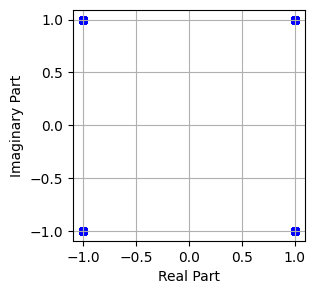

In [111]:
plot_scatter(qam_symbols)

# NEW


## Preamble Sequence - Complex Barker

In [112]:
barker_code = np.array([1+1j, 1+1j, 1+1j, 1+1j, 1+1j, -1-1j, -1-1j, 
1+1j, 1+1j, -1-1j, 1+1j, -1-1j, 1+1j])
print(barker_code)
barker_appended_qam = np.concatenate((barker_code,  qam_symbols))

print(len(barker_appended_qam))

[ 1.+1.j  1.+1.j  1.+1.j  1.+1.j  1.+1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j
 -1.-1.j  1.+1.j -1.-1.j  1.+1.j]
10017


### Zero Padded Sequence

[1.+1.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]


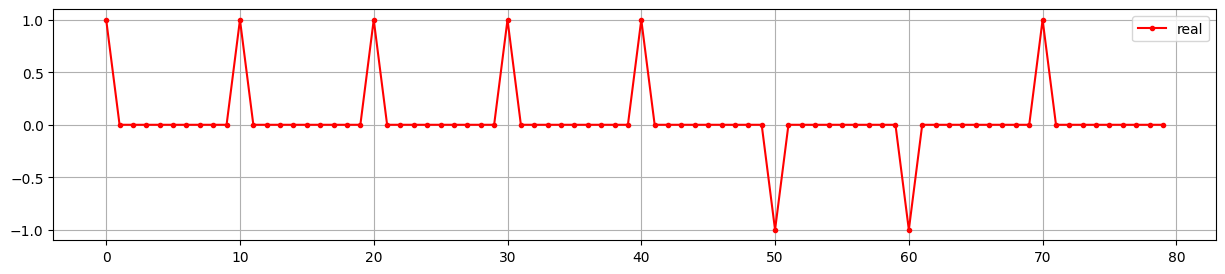

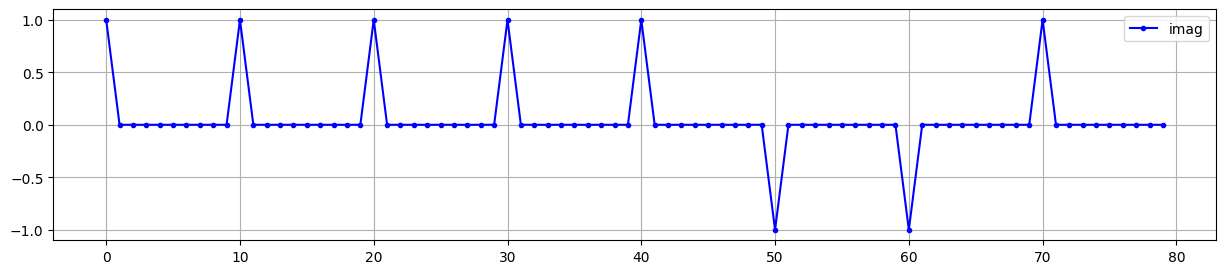

len zero padded 100170


In [113]:
sps = 10
zero_padded = np.zeros(len(barker_appended_qam) * sps, dtype=complex)
zero_padded[::sps] = barker_appended_qam
print(zero_padded)
plot_signal(zero_padded.real, 80, 'real', 'red')
plot_signal(zero_padded.imag, 80, 'imag', 'blue')
print('len zero padded', len(zero_padded))

# Pulse Shaping - Raised-Cosine Pulse

length of pulse_shaped 100170


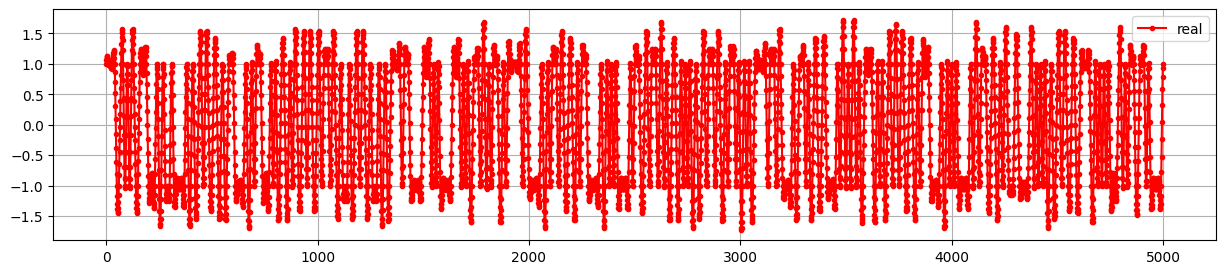

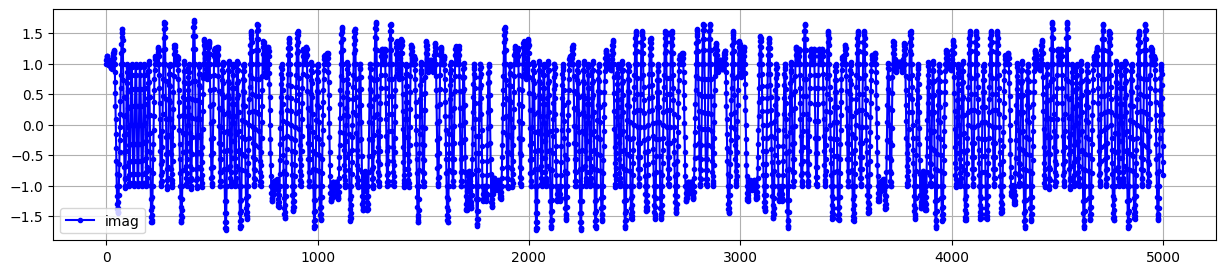

In [114]:
num_taps = 101
beta = 0.34
Ts = sps
t = np.arange(num_taps) - (num_taps-1)//2
rc_pulse = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)

ps_conv_output = np.convolve(zero_padded, rc_pulse, mode = 'full')
pulse_shaped = ps_conv_output[num_taps//2: 1+(-num_taps//2)]
print('length of pulse_shaped', len(pulse_shaped))
plot_signal(pulse_shaped.real, 5000, 'real', 'red') # Plotting first 1000 samples
plot_signal(pulse_shaped.imag, 5000, 'imag', 'blue') # Plotting first 1000 samples

### Scaling

In [115]:
tx_signal = pulse_shaped * (2**14)

# Configure SDR and Transmit

In [116]:
sample_rate = 10e6 # Hz
carrier_freq = 985e6 # Hz
num_samps = 100000 

sdr = adi.Pluto("ip:192.168.2.1")
sdr.sample_rate = int(sample_rate)

sdr.tx_rf_bandwidth = int(sample_rate) 
sdr.tx_lo = int(carrier_freq)
sdr.tx_hardwaregain_chan0 = -15

sdr.tx_cyclic_buffer = True  
sdr.tx(tx_signal) 

In [117]:
# sdr.tx_destroy_buffer()